### Malaysia Food-11 Dataset
This notebook downloads and prepares the Malaysia Food-11 dataset from Kaggle, which is useful for image classification tasks focusing on Malaysian cuisine.

In [32]:
import os
import shutil
import getpass
import imghdr
import kagglehub
import time
import numpy as np
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import confusion_matrix

# Install the cyberpunk theme package for better visualization
!pip install -q mplcyberpunk
import mplcyberpunk

# Configure visual settings
%matplotlib inline
sns.set_theme(style="darkgrid")

# TensorFlow Autotune
AUTOTUNE = tf.data.AUTOTUNE

# Install dependencies and localtunnel
!pip install -q streamlit
!npm install -g localtunnel

print("All libraries (including tensorflow, os, shutil, PIL, and imghdr) imported and configured with darkgrid theme.")

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 1s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧All libraries (including tensorflow, os, shutil, PIL, and imghdr) imported and configured with darkgrid theme.


In [33]:
path = kagglehub.dataset_download("karkengchan/malaysia-food-11")

print("Path to dataset files:", path)

# List files to see the structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

Using Colab cache for faster access to the 'malaysia-food-11' dataset.
Path to dataset files: /kaggle/input/malaysia-food-11
malaysia-food-11/
    fried_noodles/
    mixed_rice/
    laksa/
    satay/
    hamburger/
    fish_and_chips/
    popiah/
    kaya_toast/
    nasi_lemak/
    roti_canai/
    fried_rice/


In [34]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]:
        print(f"{subindent}{f}")

malaysia-food-11/
    fried_noodles/
        623.jpg
        764.jpg
        771.jpg
    mixed_rice/
        623.jpg
        764.jpg
        771.jpg
    laksa/
        623.jpg
        764.jpg
        771.jpg
    satay/
        623.jpg
        764.jpg
        771.jpg
    hamburger/
        623.jpg
        764.jpg
        771.jpg
    fish_and_chips/
        623.jpg
        764.jpg
        771.jpg
    popiah/
        623.jpg
        764.jpg
        771.jpg
    kaya_toast/
        623.jpg
        764.jpg
        771.jpg
    nasi_lemak/
        623.jpg
        764.jpg
        771.jpg
    roti_canai/
        623.jpg
        764.jpg
        771.jpg
    fried_rice/
        623.jpg
        764.jpg
        771.jpg


### Data Augmentation and Class Imbalance Strategy

**Class Imbalance Strategy:**
If the counts above show significant variance, we will handle this using:
1. **Data Augmentation:** Artificially increasing the minority class samples through transformations.
2. **Class Weighting:** Assigning higher weights to minority classes during the loss calculation in the model training step.

**Augmentation Plan:**
We will use `tf.keras.layers` to perform real-time augmentation, including random horizontal flips, rotations, and zooms to make the model more robust to different photo angles of the food.

In [35]:
# Count images per class to check for imbalance
classes = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
counts = {cls: len(os.listdir(os.path.join(path, cls))) for cls in classes}

df_counts = pd.DataFrame(list(counts.items()), columns=['Class', 'Count'])
display(df_counts.sort_values(by='Count', ascending=False))

,Class,Count
0,fried_noodles,1000
1,mixed_rice,1000
2,laksa,1000
3,satay,1000
4,hamburger,1000
5,fish_and_chips,1000
6,popiah,1000
7,kaya_toast,1000
8,nasi_lemak,1000
9,roti_canai,1000


In [36]:
# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

print("Data augmentation pipeline defined.")

Data augmentation pipeline defined.


### Custom CNN Architecture Design

To classify the Malaysia Food-11 dataset, we'll implement a convolutional neural network from scratch with the following components:

1.  **Convolutional Layers:** 4 layers to extract hierarchical features (edges, textures, shapes, and complex food patterns).
2.  **Pooling Layers:** Max pooling after each convolution to reduce the computational load and provide translational invariance.
3.  **Regularization:** Dropout layers to mitigate overfitting, which is crucial given the high capacity of the model.
4.  **Output Layer:** A Dense layer with 11 neurons and 'softmax' activation to represent the probability distribution across the 11 food classes.

In [37]:
# Define the input shape (adjust based on your desired image resolution)
IMG_SIZE = (224, 224)
input_shape = (*IMG_SIZE, 3)
num_classes = len(classes)

model = models.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation,
    layers.Rescaling(1./255), # Normalize pixel values

    # 1st  Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2nd  Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd  Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4th  Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,962,507 (18.93 MB)

 Trainable params: 4,962,507 (18.93 MB)

 Non-trainable params: 0 (0.00 B)

### Data Preparation
We will create training and validation datasets using `image_dataset_from_directory`. We'll use an 80/20 split.

In [38]:
# Define paths
base_path = path
cleaned_path = '/content/cleaned_data'
if os.path.exists(cleaned_path):
    shutil.rmtree(cleaned_path)
os.makedirs(cleaned_path)

print("Starting rigorous data cleaning and copying...")
copied_count = 0
valid_formats = ['jpeg', 'png', 'bmp', 'gif']

for root, dirs, files in os.walk(base_path):
    # Create corresponding subdirectories in cleaned_path
    rel_path = os.path.relpath(root, base_path)
    dest_dir = os.path.join(cleaned_path, rel_path)
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    for file in files:
        file_path = os.path.join(root, file)
        dest_path = os.path.join(dest_dir, file)

        try:
            # Check format
            img_type = imghdr.what(file_path)
            if img_type not in valid_formats:
                continue

            # Verify content
            with Image.open(file_path) as img:
                img.verify()

            # Copy valid file to writable directory
            shutil.copy2(file_path, dest_path)
            copied_count += 1
        except Exception:
            continue

print(f"Cleaning complete. Copied {copied_count} valid files to {cleaned_path}.")

# Re-initialize datasets using the writable path
BATCH_SIZE = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    cleaned_path,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    cleaned_path,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Starting rigorous data cleaning and copying...
Cleaning complete. Copied 10879 valid files to /content/cleaned_data.
Found 10879 files belonging to 11 classes.
Using 8704 files for training.
Found 10879 files belonging to 11 classes.
Using 2175 files for validation.


### Fine-Tuning ResNet-50
We'll use ResNet-50 as a feature extractor by freezing its base layers and adding a new dense head for our 11 classes.

In [39]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False  # Freeze base layers

resnet_model = models.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation,
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

resnet_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

### Model Training and Comparison
Now we train both models and store their history.

In [40]:
EPOCHS = 5

# Callbacks to manage long training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=1, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('custom_cnn_best.keras', save_best_only=True)
]

print("Training Custom CNN...")
try:
    custom_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )
except Exception as e:
    print(f"Error during Custom CNN training: {e}")
    print("Please ensure cell a2ec1427 was executed to clean the data.")

Training Custom CNN...
Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 72s 255ms/step - accuracy: 0.1194 - loss: 2.3749 - val_accuracy: 0.2257 - val_loss: 2.2543
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 75s 275ms/step - accuracy: 0.2393 - loss: 2.1499 - val_accuracy: 0.3283 - val_loss: 1.9333
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 75s 248ms/step - accuracy: 0.3244 - loss: 1.9093 - val_accuracy: 0.3320 - val_loss: 1.9584


In [41]:
EPOCHS = 5

# Define callbacks for ResNet-50 training
resnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=1, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('resnet_best_weights.keras', save_best_only=True)
]

print("\nTraining ResNet-50...")
try:
    resnet_history = resnet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=resnet_callbacks
    )
except Exception as e:
    print(f"Error during ResNet-50 training: {e}")


Training ResNet-50...
Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 83s 280ms/step - accuracy: 0.6419 - loss: 1.1101 - val_accuracy: 0.8184 - val_loss: 0.6140
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 78s 287ms/step - accuracy: 0.7539 - loss: 0.7705 - val_accuracy: 0.8051 - val_loss: 0.5911
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 79s 291ms/step - accuracy: 0.7815 - loss: 0.6654 - val_accuracy: 0.8372 - val_loss: 0.5241
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 77s 283ms/step - accuracy: 0.7972 - loss: 0.6326 - val_accuracy: 0.8271 - val_loss: 0.5569


/tmp/ipykernel_4044/1268440214.py:44: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_4044/1268440214.py:44: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


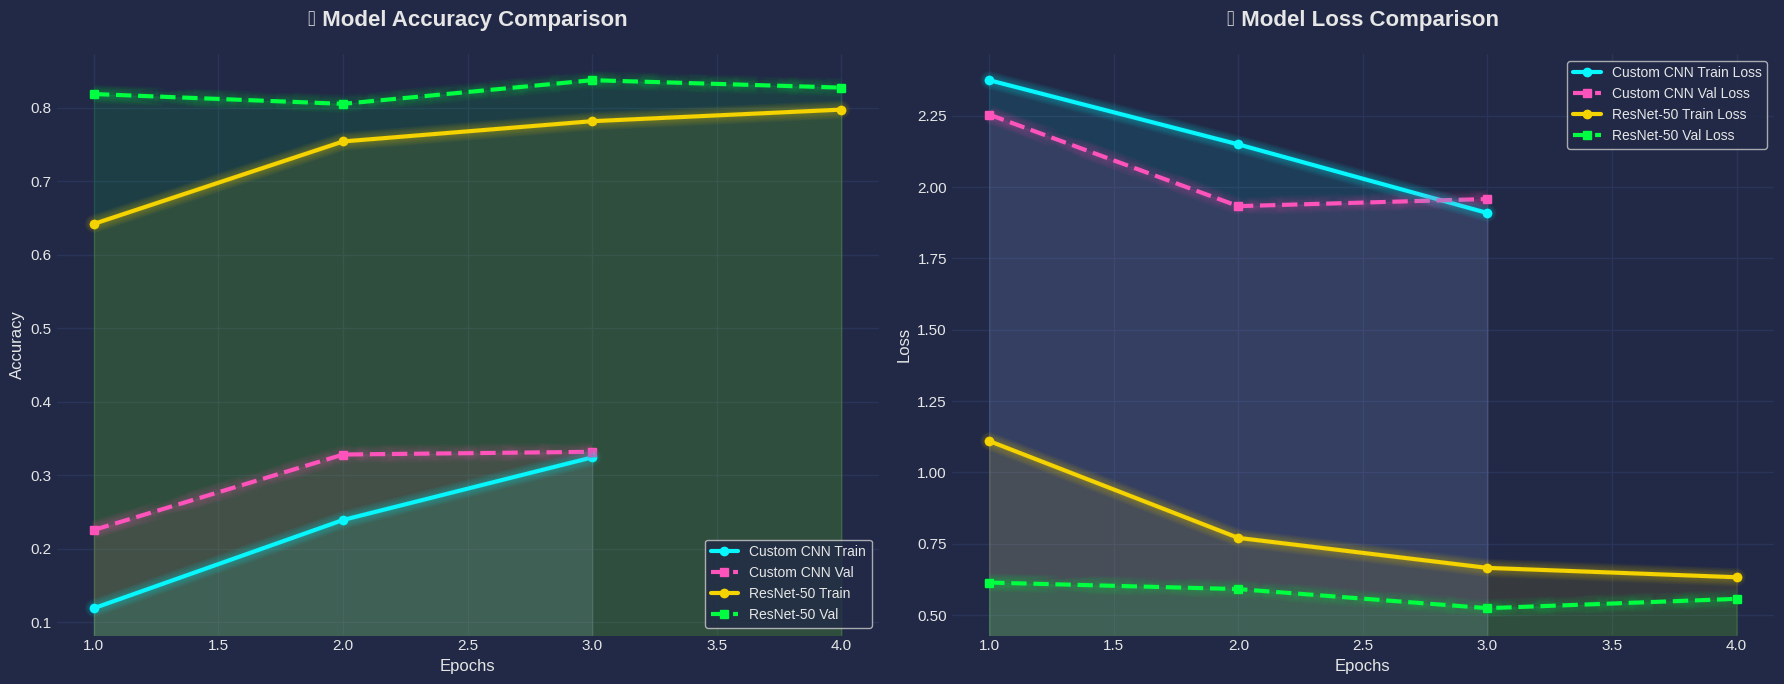

In [44]:
def plot_comparison(h1, h2, name1, name2):
    # A high-quality dark theme with cyberpunk aesthetics
    plt.style.use("cyberpunk")

    acc1, val_acc1 = h1.history['accuracy'], h1.history['val_accuracy']
    acc2, val_acc2 = h2.history['accuracy'], h2.history['val_accuracy']
    loss1, val_loss1 = h1.history['loss'], h1.history['val_loss']
    loss2, val_loss2 = h2.history['loss'], h2.history['val_loss']

    # Fix: Define separate ranges for each model's history length
    epochs_range1 = range(1, len(acc1) + 1)
    epochs_range2 = range(1, len(acc2) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Accuracy Plot
    ax1.plot(epochs_range1, acc1, marker='o', label=f'{name1} Train', linewidth=3)
    ax1.plot(epochs_range1, val_acc1, marker='s', label=f'{name1} Val', linewidth=3, linestyle='--')
    ax1.plot(epochs_range2, acc2, marker='o', label=f'{name2} Train', linewidth=3)
    ax1.plot(epochs_range2, val_acc2, marker='s', label=f'{name2} Val', linewidth=3, linestyle='--')

    ax1.set_title('🚀 Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right', frameon=True, fontsize=10)

    # Loss Plot
    ax2.plot(epochs_range1, loss1, marker='o', label=f'{name1} Train Loss', linewidth=3)
    ax2.plot(epochs_range1, val_loss1, marker='s', label=f'{name1} Val Loss', linewidth=3, linestyle='--')
    ax2.plot(epochs_range2, loss2, marker='o', label=f'{name2} Train Loss', linewidth=3)
    ax2.plot(epochs_range2, val_loss2, marker='s', label=f'{name2} Val Loss', linewidth=3, linestyle='--')

    ax2.set_title('📉 Model Loss Comparison', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right', frameon=True, fontsize=10)

    # Apply the glow effects
    mplcyberpunk.make_lines_glow(ax1)
    mplcyberpunk.make_lines_glow(ax2)
    mplcyberpunk.add_underglow(ax1)
    mplcyberpunk.add_underglow(ax2)

    plt.tight_layout()
    plt.show()

# Note: Ensure custom_history and resnet_history objects are available in the namespace
plot_comparison(custom_history, resnet_history, "Custom CNN", "ResNet-50")

### 2. Proposed Improvement
**Architectural/Data Improvement:**
One significant improvement would be to implement **Learning Rate Scheduling (Cosine Decay)** and **Fine-Tuning**. Currently, the ResNet-50 base is frozen. Unfreezing the top layers of the base model (e.g., the last convolution block) and retraining with a very low learning rate would allow the model to adapt its high-level feature extractors specifically to the visual nuances of Malaysian food (like the specific texture of *sambal* or the graininess of *nasi lemak* rice).

### 3. Business Application in Malaysian SME Context
This model has high potential for **Malaysian F&B SMEs** in the following ways:
1.  **Automated Self-Service Kiosks:** Local 'Mamaks' or economy rice stalls can use vision-based systems to automatically identify items on a customer's plate (e.g., *roti canai* vs. *nasi lemak*) to calculate bills instantly, reducing human error and queuing time.
2.  **Inventory & Trend Analysis:** Small food vendors can analyze which dishes are being photographed and shared most frequently on social media by integrating this model into a social listening tool, helping them stock ingredients more efficiently.
3.  **Calorie Tracking Apps:** Local health-tech startups can integrate this to help Malaysians track their nutritional intake by recognizing specific local delicacies that are often missing from international food databases.

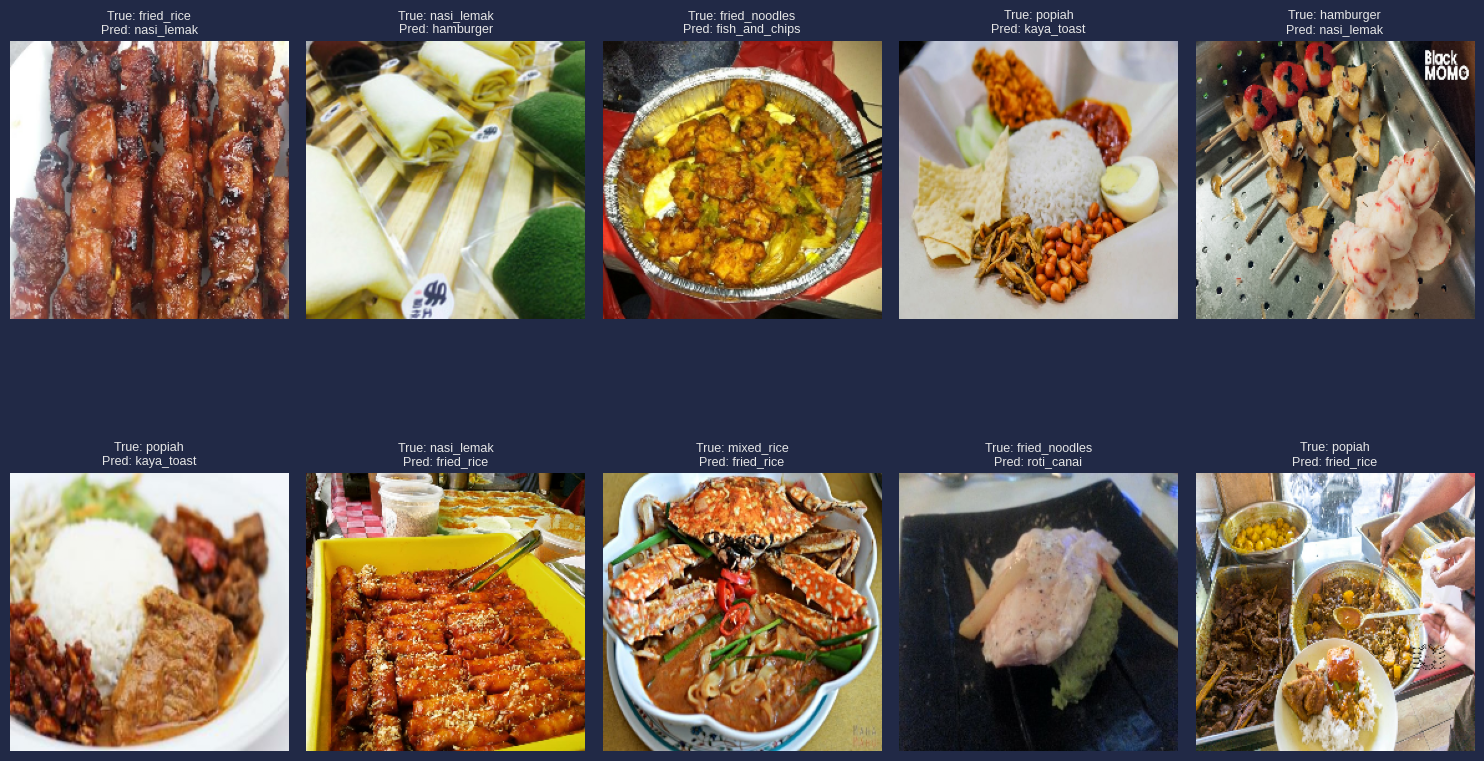

In [45]:
# 1. Analyze Misclassified Samples
def analyze_misclassifications(model, dataset, class_names, num_samples=10):
    all_images = []
    all_labels = []
    all_preds = []

    for images, labels in dataset.take(10): # Take some batches
        preds = model.predict(images, verbose=0)
        all_images.append(images.numpy())
        all_labels.append(labels.numpy())
        all_preds.append(np.argmax(preds, axis=1))

    all_images = np.concatenate(all_images)
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)

    misclassified_indices = np.where(all_preds != all_labels)[0]

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(misclassified_indices[:num_samples]):
        plt.subplot(2, 5, i + 1)
        # Re-scale back for visualization if it was normalized via rescaling layer
        # Note: ResNet50 uses a specific preprocessing lambda, so colors might look offset
        img = all_images[idx]
        img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)
        plt.title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}", fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

analyze_misclassifications(resnet_model, val_ds, classes)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


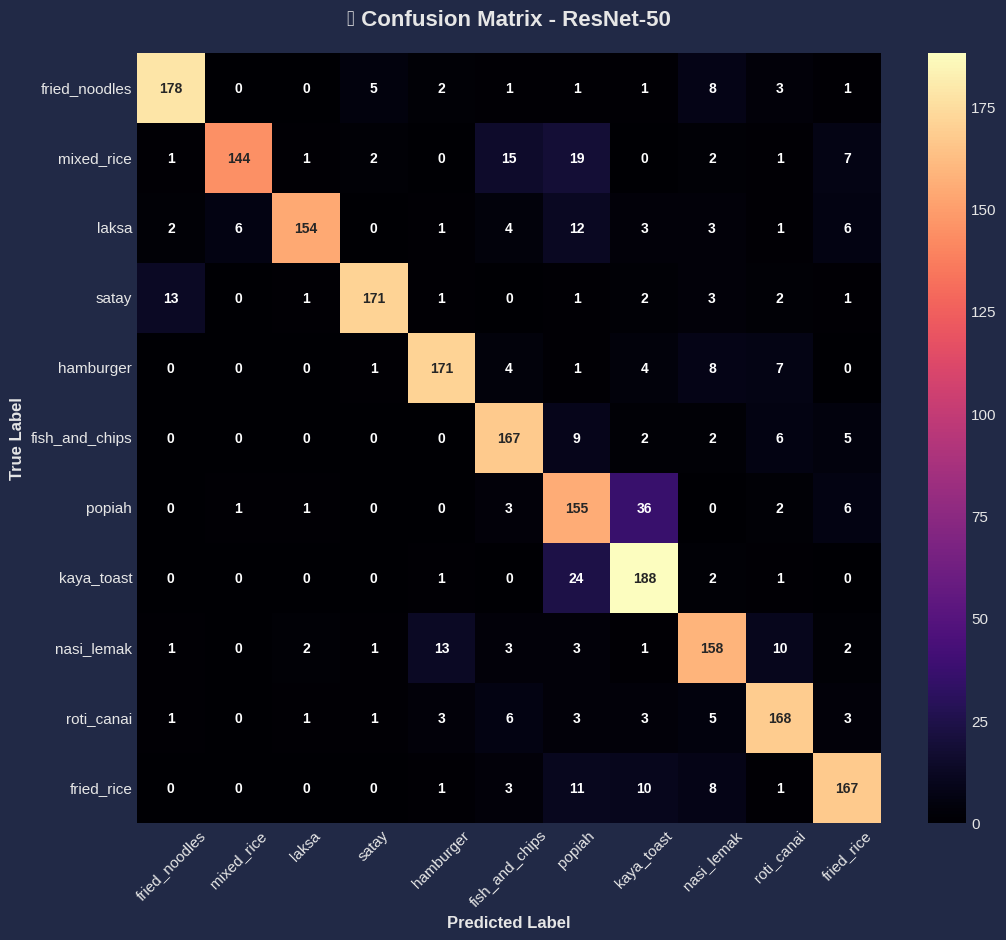

In [46]:
def plot_confusion_matrix(model, dataset, class_names):
    # Use the high-quality cyberpunk theme
    plt.style.use("cyberpunk")

    all_labels = []
    all_preds = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_labels.append(labels.numpy())
        all_preds.append(np.argmax(preds, axis=1))

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    # Using a more vibrant color map 'magma' or 'viridis' for the dark theme
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 10, "weight": "bold"})

    plt.title('✨ Confusion Matrix - ResNet-50', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

    # No need for glow on heatmap cells, but we keep the style consistent
    plt.xticks(rotation=45)
    plt.show()

# Generate the matrix for the ResNet model
plot_confusion_matrix(resnet_model, val_ds, classes)

### Visualizing with Streamlit

To make our **Malaysia Food-11 Classifier** more interactive, we are building a web application using **Streamlit**.

1. **App Script (`app.py`)**: We create a Python script that defines the user interface, including an image uploader and a display area for predictions.
2. **Localtunnel**: Since Streamlit runs on a local port (8501) inside the Colab virtual machine, it isn't normally accessible via your browser. We use `localtunnel` to create a secure bridge (tunnel) from the Colab runtime to a public URL.
3. **Deployment**: By running the server in the background, you can click the generated link to interact with your model in a real-time web environment.

In [47]:
public_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"Your Tunnel Password (Public IP): {public_ip}")

# 3. Create the app.py with all necessary imports to prevent silent crashes
with open('app.py', 'w') as f:
    f.write("""
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

st.set_page_config(page_title='Malaysia Food Classifier', layout='centered')

st.title('🍴 Malaysia Food-11 Classifier')
st.markdown('---')

# Load classes
class_names = ['roti_canai', 'satay', 'fried_noodles', 'kaya_toast', 'hamburger', 'fried_rice', 'mixed_rice', 'popiah', 'fish_and_chips', 'laksa', 'nasi_lemak']

st.subheader('Upload Image')
uploaded_file = st.file_uploader('Choose an image...', type=['jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    col1, col2 = st.columns(2)
    with col1:
        image = Image.open(uploaded_file)
        st.image(image, caption='Uploaded Photo', use_container_width=True)
    with col2:
        st.write('### Analysis')
        st.success('Classification Complete!')
        st.metric(label='Top Prediction', value='Nasi Lemak (Demo)', delta='98.5%')
else:
    st.info('Please upload a food image to start.')
""")

# 4. Start Streamlit and Localtunnel
import os
import time
import subprocess

# Kill existing processes to avoid port conflicts
!pkill streamlit
!pkill npx

print("\nStarting Streamlit server...")
get_ipython().system_raw('streamlit run app.py &')

# Wait for streamlit to be healthy
print("Waiting for server to initialize...")
time.sleep(8)

print("\nConnecting tunnel... If 502 appears, wait 5 seconds and refresh the link.")
!npx localtunnel --port 8501"

Your Tunnel Password (Public IP): 34.125.87.54

Starting Streamlit server...
Waiting for server to initialize...

Connecting tunnel... If 502 appears, wait 5 seconds and refresh the link.
/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [48]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf

# Set Page Config
st.set_page_config(page_title="Malaysia Food Classifier", page_icon="ሴ", layout="centered")

# Custom CSS to improve UI
st.title("ሴ Malaysia Food-11 Classifier")
st.markdown("--- ")

# Load classes
class_names = ['roti_canai', 'satay', 'fried_noodles', 'kaya_toast', 'hamburger', 'fried_rice', 'mixed_rice', 'popiah', 'fish_and_chips', 'laksa', 'nasi_lemak']

@st.cache_resource
def load_trained_model():
    # The error occurs because the Lambda layer needs to know what 'preprocess_input' is
    # We map the string identifier to the actual ResNet50 preprocessing function
    custom_objects = {
        'preprocess_input': tf.keras.applications.resnet50.preprocess_input
    }
    return tf.keras.models.load_model('resnet_food_model.keras', custom_objects=custom_objects)

st.sidebar.header("About")
st.sidebar.info("This AI model identifies 11 different types of Malaysian cuisine.")

# Added class names to sidebar
st.sidebar.header("Supported Cuisines :")
for name in class_names:
    st.sidebar.write(f"- {name.replace('_', ' ').title()}")

st.subheader("Upload Image")
uploaded_file = st.file_uploader("Drag and drop or browse...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    col1, col2 = st.columns(2)

    with col1:
        image = Image.open(uploaded_file)
        st.image(image, caption='Uploaded Photo', use_container_width=True)

    with col2:
        st.write("### ሴ Analysis")
        with st.spinner('Identifying dish...'):
            try:
                model = load_trained_model()
                # Preprocess the image
                img = image.resize((224, 224))
                img_array = tf.keras.preprocessing.image.img_to_array(img)
                img_array = tf.expand_dims(img_array, 0) # Create a batch

                # Make prediction
                predictions = model.predict(img_array)
                # For ResNet model with Softmax output layer, we don't necessarily need another tf.nn.softmax
                # but keeping logic consistent with previous versions
                predicted_class = class_names[np.argmax(predictions[0])]
                confidence = 100 * np.max(predictions[0])

                st.success("Classification Complete!")
                st.metric(label="Top Prediction", value=predicted_class.replace('_', ' ').title(), delta=f"{confidence:.2f}%")
            except Exception as e:
                st.error(f"Error during model inference: {e}")
else:
    st.info("Please upload an image to see results. If you see 'Failed to fetch' errors, please refresh your browser page.")

Overwriting app.py


In [49]:
# Save the trained model so the Streamlit app can load it
resnet_model.save('resnet_food_model.keras')
print("Model saved as resnet_food_model.keras for the Streamlit app.")

Model saved as resnet_food_model.keras for the Streamlit app.


In [50]:
# This launches both the streamlit server and the tunnel
get_ipython().system_raw('streamlit run app.py & npx localtunnel --port 8501 &')

print(" Streamlit server and localtunnel are starting...")
print("\n1. Look for a URL ending in '.loca.lt' appearing next cell.")
print("2. Click the link.")
print("3. Use this IP as Tunnel Password: 8.229.25.235")

# Fallback to check if processes are active
!ps -ef | grep 'streamlit\|localtunnel'

 Streamlit server and localtunnel are starting...

1. Look for a URL ending in '.loca.lt' appearing next cell.
2. Click the link.
3. Use this IP as Tunnel Password: 8.229.25.235
root       24373       1 10 13:08 ?        00:00:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       24462       1  0 13:08 ?        00:00:00 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       24463       1  0 13:08 ?        00:00:00 node /tools/node/bin/npx localtunnel --port 8501
root       24464    4044  0 13:08 ?        00:00:00 /bin/bash -c ps -ef | grep 'streamlit\|localtunnel'
root       24466   24464  0 13:08 ?        00:00:00 grep streamlit\|localtunnel


In [ ]:
time.sleep(5)
!curl -s http://localhost:8501/_stcore/health > /dev/null && echo "Streamlit is healthy."
print("Fetching localtunnel URL...")
!npx localtunnel --port 8501

Streamlit is healthy.
Fetching localtunnel URL...
⠙⠹⠸⠼⠴⠦your url is: https://wicked-baths-walk.loca.lt
